# HW2P2: Image Recognition and Verification

This is the second homework  in 11785: Introduction to Deep Learning. We are trying to tackle the problem of Image Verification. For this, we will need to first train our own CNN model to tackle the problem of classification, consisting of 8631 identities. Using this, we get the face embeddings for different pairs of images and try to identify if the pair of face matches or not.

**Instructions about running this Notebook:**
1. This notebook can be run pretty much sequentially as the following processes of the assignment are organized in sequential manner.
  1. Pre-training the classification model
  2. Any continuation of training the classification model
  3. Fine-tuning classification model for verification task

This is the link to the wandb report for hw2p2 showing the runs that comprise the final result: https://api.wandb.ai/links/pkotchav-carnegie-mellon-university/jopdv8e7. I am not able to make the project public as the option isn't available for some reason, but I would be happy to work through and provide the entire project if possible/needed.
The weight file needed to load the model as each stage and log files are as follows:
1. The model after 1st round of Classification Pre-Training: resnet18-r8-NewPreTrain.txt & R8_best_cls.pth
2. The model after continuation of Classification Pre-Training: resnet18-r8-continueTraining.txt & cont_R8_best_eer4.pth
3. The model after Verification Fine-Tuning: resnet18-r8-higherRetTune16.txt & VerTune8_best_ret4.pth


# Libraries

In [ ]:
!nvidia-smi # Run this to see what GPU you have

Wed Oct 16 05:42:39 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   52C    P8              12W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
!pip install wandb --quiet # Install WandB
!pip install pytorch_metric_learning --quiet #Install the Pytorch Metric Library

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.8/313.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 8.0 MB/s eta 0:00:00


In [ ]:
import torch
from torchsummary import summary
import torchvision
from torchvision import transforms
import torch.nn.functional as F
import os
import gc
from tqdm import tqdm
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn import metrics as mt
from scipy.optimize import brentq
from scipy.interpolate import interp1d
import glob
import wandb
import matplotlib.pyplot as plt
from pytorch_metric_learning import samplers
from pytorch_metric_learning import losses

import csv

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", DEVICE)


Device:  cuda


In [ ]:
# from google.colab import drive # Link to your drive if you are not using Colab with GCP
# drive.mount('/content/drive') # Models in this HW take a long time to get trained and make sure to save it here

# Kaggle

In [ ]:
# TODO: Use the same Kaggle code from HW1P2
!pip install --upgrade --force-reinstall --no-deps kaggle==1.5.8
!mkdir /root/.kaggle

with open("/root/.kaggle/kaggle.json", "w+") as f:
    f.write('{"username":"paulkotchavong","key":""}')
    # Put your kaggle username & key here

!chmod 600 /root/.kaggle/kaggle.json

  Using cached kaggle-1.5.8-py3-none-any.whl
  Attempting uninstall: kaggle
    Found existing installation: kaggle 1.5.8
    Uninstalling kaggle-1.5.8:
      Successfully uninstalled kaggle-1.5.8


In [ ]:
# Reminder: Make sure you have connected your kaggle API before running this block
!mkdir '/content/data'

!kaggle competitions download -c 11785-hw-2-p-2-face-verification-fall-2024
!unzip -qo '11785-hw-2-p-2-face-verification-fall-2024.zip' -d '/content/data'

100% 2.74G/2.75G [00:17<00:00, 194MB/s]
100% 2.75G/2.75G [00:17<00:00, 167MB/s]


# Config

In [ ]:
config = {
    'batch_size': 128, # Increase this if your GPU can handle it
    'lr': 0.1,
    'epochs': 40, # 20 epochs is recommended ONLY for the early submission - you will have to train for much longer typically.
    'data_dir': "/content/data/11-785-f24-hw2p2-verification/cls_data", #TODO
    'data_ver_dir': "/content/data/11-785-f24-hw2p2-verification/ver_data", #TODO
    'checkpoint_dir': "/content/hw2p2/run1", #TODO
    # Include other parameters as needed.
    'model_type': 'resnet50 No Bottlenneck',
    'cls_scheduler': 'OneCycleLR w/ divFactor 10 and finalDivFactor 1000',
    'cls_optimizer': 'sgd',
    'ver_scheduler': 'None',
    'ver_optimizer': 'None',
    'loss': 'cross_entropy_smoothing',
    'loss2': 'ArcFace',
}

In [ ]:
print(os.getcwd())


/content


# Dataset

## Dataset Class for doing Image Verification

In [ ]:
class ImagePairDataset(torch.utils.data.Dataset):

    def __init__(self, data_dir, csv_file, transform):
        self.data_dir = data_dir
        self.transform = transform
        self.pairs = []
        if csv_file.endswith('.csv'):
            with open(csv_file, 'r') as f:
                reader = csv.reader(f)
                for i, row in enumerate(reader):
                    if i == 0:
                        continue
                    else:
                        self.pairs.append(row)
        else:
            with open(csv_file, 'r') as f:
                for line in f.readlines():
                    self.pairs.append(line.strip().split(' '))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img_path1, img_path2, match = self.pairs[idx]
        img1 = Image.open(os.path.join(self.data_dir, img_path1))
        img2 = Image.open(os.path.join(self.data_dir, img_path2))
        return self.transform(img1), self.transform(img2), int(match)

In [ ]:
class TestImagePairDataset(torch.utils.data.Dataset):

    def __init__(self, data_dir, csv_file, transform):
        self.data_dir = data_dir
        self.transform = transform
        self.pairs = []
        if csv_file.endswith('.csv'):
            with open(csv_file, 'r') as f:
                reader = csv.reader(f)
                for i, row in enumerate(reader):
                    if i == 0:
                        continue
                    else:
                        self.pairs.append(row)
        else:
            with open(csv_file, 'r') as f:
                for line in f.readlines():
                    self.pairs.append(line.strip().split(' '))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        img_path1, img_path2 = self.pairs[idx]
        img1 = Image.open(os.path.join(self.data_dir, img_path1))
        img2 = Image.open(os.path.join(self.data_dir, img_path2))
        return self.transform(img1), self.transform(img2)

## Create Dataloaders for Image Recognition

Created a class that loads an image and perform cutout on a single image

In [ ]:
# create cutout function for cutout augmentation
class Cutout(object):
    """Randomly mask out one or more patches from an image.
    """
    def __init__(self, cutout_size, probability=0.5):
        self.cutout_size = cutout_size
        self.probability = probability

    def __call__(self, image):
        if np.random.rand() > self.probability:
            return image

        h, w = image.size(1), image.size(2)
        mask = np.ones((h, w), np.float32)

        center_area_size = 0.6  # 50% of the image size can be centered

        y_c = np.random.randint(int(h * (1 - center_area_size) / 2), int(h * (1 + center_area_size) / 2))
        x_c = np.random.randint(int(w * (1 - center_area_size) / 2), int(w * (1 + center_area_size) / 2))

        y1 = np.clip(y_c - self.cutout_size // 2, 0, h)
        y2 = np.clip(y_c + self.cutout_size // 2, 0, h)
        x1 = np.clip(x_c - self.cutout_size // 2, 0, w)
        x2 = np.clip(x_c + self.cutout_size // 2, 0, w)

        mask[y1: y2, x1: x2] = 0.
        mask = torch.from_numpy(mask).unsqueeze(0).expand_as(image)
        image = image * mask

        return image

Create a class that does cutmix on a batch of images; cutting patches from random image in the batch and paste it on random other images in the patch. There is a probability parameter that randomly determines whether the current batch will have cutmix.

In [ ]:
class CutMix(object):
    def __init__(self, alpha):
        self.alpha = alpha

    def __call__(self, batch_imgs, batch_labels):
        if np.random.rand() > 0.5:
            lam = np.random.beta(self.alpha, self.alpha)
            indices = torch.randperm(batch_imgs.size(0))
            shuffled_imgs = batch_imgs[indices]
            shuffled_labels = batch_labels[indices]

            W, H = batch_imgs.size(2), batch_imgs.size(3)
            ratio = np.sqrt( 1. - lam)
            w_cut = max(int(W * ratio), 1)
            h_cut = max(int(H * ratio), 1)
            cx, cy = np.random.randint(w_cut), np.random.randint(h_cut)
            bbx1 = np.clip(cx - w_cut // 2, 0, W)
            bby1 = np.clip(cy - h_cut // 2, 0, H)
            bbx2 = np.clip(cx + w_cut // 2, 0, W)
            bby2 = np.clip(cy + h_cut // 2, 0, H)

            batch_imgs[:, :, bbx1:bbx2, bby1:bby2] = shuffled_imgs[:, :, bbx1:bbx2, bby1:bby2]
            lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
            batch_labels = (1 - lam) * batch_labels + lam * shuffled_labels
            batch_labels = batch_labels.long()
            return batch_imgs, batch_labels
        else:
            lam = 1
            return batch_imgs, batch_labels

Ultimately, I decided to turn the above cutmix class (which could be called and used in the composed tranform list in torchvision.transforms.Compose) into a collate function to use with dataloader instead.

In [ ]:
def cutmix_collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels)

    batch_size = len(images)

    if np.random.rand() < 0.5:
      # Generate random parameters for CutMix
      lam = np.random.beta(1.0, 1.0)
      rand_index = torch.randperm(batch_size)

      # Get image size
      _, h, w = images[0].shape

      # Generate random bounding box
      cut_rat = np.sqrt(1.0 - lam)
      cut_w = int(w * cut_rat)
      cut_h = int(h * cut_rat)

      cx = np.random.randint(w)
      cy = np.random.randint(h)

      bbx1 = np.clip(cx - cut_w // 2, 0, w)
      bby1 = np.clip(cy - cut_h // 2, 0, h)
      bbx2 = np.clip(cx + cut_w // 2, 0, w)
      bby2 = np.clip(cy + cut_h // 2, 0, h)

      # Apply CutMix
      images[:, :, bby1:bby2, bbx1:bbx2] = images[rand_index, :, bby1:bby2, bbx1:bbx2]

      # Adjust labels
      lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (w * h))
      target_a = labels
      target_b = labels[rand_index]

      return images, (target_a, target_b, lam)
    else:
      return images, labels

Load data and apply following transforms listed. Cutmixed was not used in the final model used as best submission

In [ ]:
data_dir = config['data_dir']
# train_dir = os.path.join(data_dir)

train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'dev')

# train transforms
train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(112), # Why are we resizing the Image?
    torchvision.transforms.RandomResizedCrop(112, scale=(0.8, 1.0)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomRotation(degrees=15),
    torchvision.transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    torchvision.transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    torchvision.transforms.ToTensor(),
    Cutout(cutout_size=32),
    torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                      std=[0.5, 0.5, 0.5]),
    torchvision.transforms.RandomErasing(p=0.2, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0)])

# val transforms
val_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(128),
    torchvision.transforms.CenterCrop(112),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                      std=[0.5, 0.5, 0.5])])


# get datasets
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                            batch_size=config["batch_size"],
                                            shuffle=True,
                                            pin_memory=True,
                                            num_workers=4,
                                            sampler=None)
val_loader = torch.utils.data.DataLoader(val_dataset,
                                          batch_size=config["batch_size"],
                                          shuffle=False,
                                          num_workers=4)

**THIS CELL DOES NOT NEED TO BE RUN as it was used to visualize cutmix for sanity check** Cutmix was not used in the final model

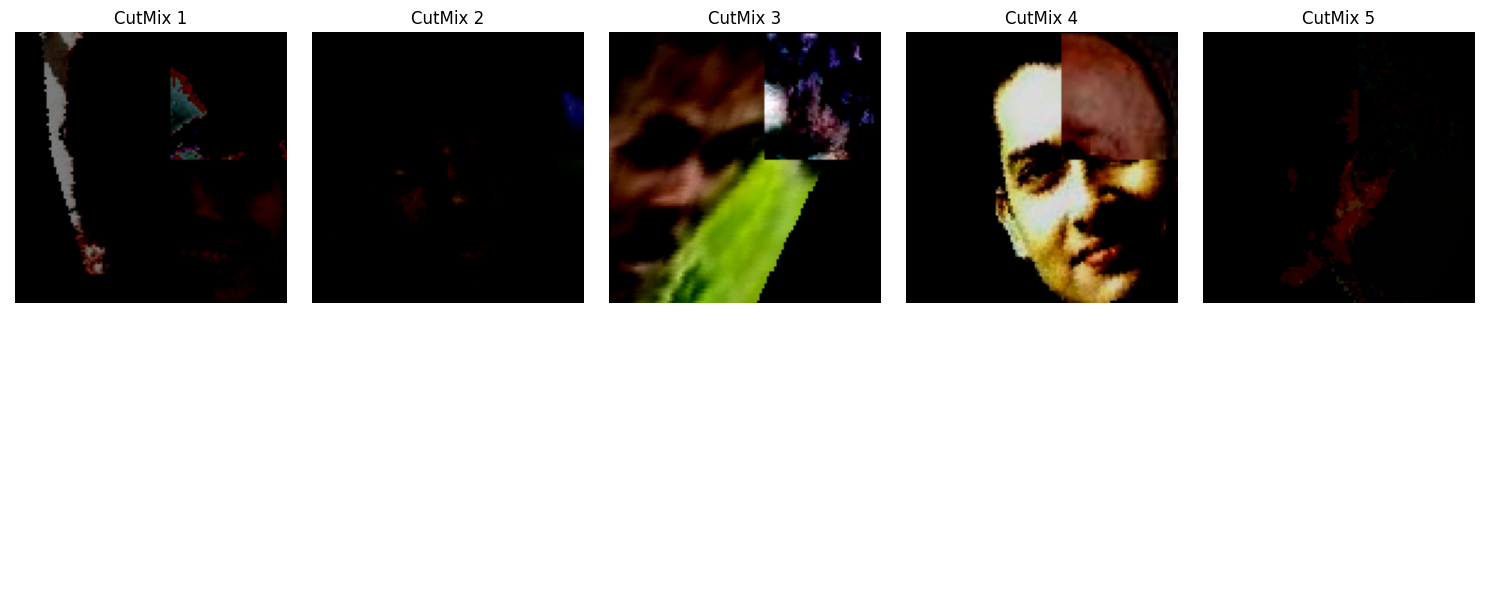

Lambda (mixing ratio): 0.8010204081632653
Target A: tensor([5056, 2074, 1512, 3731, 8594])
Target B: tensor([3230, 6601, 1938, 7962, 3863])


In [ ]:
def visualize_cutmix(dataloader, num_samples=5):
    # Get a batch of data
    images, (target_a, target_b, lam) = next(iter(dataloader))

    # Ensure we don't exceed the batch size
    num_samples = min(num_samples, images.shape[0])

    # Convert images from tensor to numpy for plotting
    images_np = images[:num_samples].permute(0, 2, 3, 1).cpu().numpy()

    # Plot the images
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

    for i in range(num_samples):
        # Plot CutMix image
        axes[0, i].imshow(np.clip(images_np[i], 0, 1))
        axes[0, i].set_title(f"CutMix {i+1}")
        axes[0, i].axis('off')

        # We can't easily get the original images here, so we'll leave the bottom row empty
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

    print(f"Lambda (mixing ratio): {lam}")
    print(f"Target A: {target_a[:num_samples]}")
    print(f"Target B: {target_b[:num_samples]}")

visualize_cutmix(train_loader)

In [ ]:
data_dir = config['data_ver_dir']


# get datasets

# TODO: Add your validation pair txt file
pair_dataset = ImagePairDataset(data_dir, csv_file='/content/data/11-785-f24-hw2p2-verification/val_pairs.txt', transform=val_transforms)
pair_dataloader = torch.utils.data.DataLoader(pair_dataset,
                                              batch_size=config["batch_size"],
                                              shuffle=False,
                                              pin_memory=True,
                                              num_workers=4)

# TODO: Add your validation pair txt file
test_pair_dataset = TestImagePairDataset(data_dir, csv_file='/content/data/11-785-f24-hw2p2-verification/test_pairs.txt', transform=val_transforms)
test_pair_dataloader = torch.utils.data.DataLoader(test_pair_dataset,
                                              batch_size=config["batch_size"],
                                              shuffle=False,
                                              pin_memory=True,
                                              num_workers=4)

In [ ]:
print(len(pair_dataset))
print(len(test_pair_dataset))
print(len(train_dataset))
print(len(val_dataset))
print("Number of classes    : ", len(train_dataset.classes))

1000
6000
431550
43155
Number of classes    :  8631


# EDA and Viz

In [ ]:
# Double-check your dataset/dataloaders work as expected

print("Number of classes    : ", len(val_dataset.classes))
print("No. of train images  : ", train_dataset.__len__())
print("Shape of image       : ", train_dataset[0][0].shape)
print("Batch size           : ", config['batch_size'])
print("Train batches        : ", train_loader.__len__())
print("Val batches          : ", val_loader.__len__())

# Feel free to print more things if needed

Number of classes    :  8631
No. of train images  :  431550
Shape of image       :  torch.Size([3, 112, 112])
Batch size           :  128
Train batches        :  3372
Val batches          :  338


tensor([1148, 8272, 5888,   17, 7089, 8627,  356, 8554, 7507, 5324, 5073, 4747,
        3938, 7244, 2312,  624, 6447, 6705, 5359,   95,  289,  666, 3207, 5010,
        8511, 7834, 3828, 5019, 8303, 6222, 5487,  190, 5379, 2079, 1561, 8021,
        5308,  499, 1526,  783, 5944, 7633, 6011, 7593, 2570, 7613, 6664, 2575,
        7721, 4138, 5219, 5963, 6347, 1910, 5851, 3332, 2457, 6403, 5175, 3763,
        8225, 5120,  672, 3978, 1708, 1068, 5774, 6197,  465, 1802, 3949, 8262,
        2608, 3254, 4270, 2482, 8100, 5566, 1801, 7290, 1339,  807, 5691, 2971,
         147, 3527, 2732, 2311, 5143, 8488, 5847, 1441, 2431, 7832,  631,  427,
        7292, 3167, 8284, 8329, 6392, 5493, 7146, 3362, 5385, 7890, 2332, 4008,
        1314, 4747, 4620, 6055, 8486,  959, 5899, 3570, 2012, 8558, 5357, 8456,
        4694, 5381, 1274, 3542, 6147, 8085, 6904, 3053])
tensor(1148)
tensor(8272)
tensor(5888)
tensor(17)


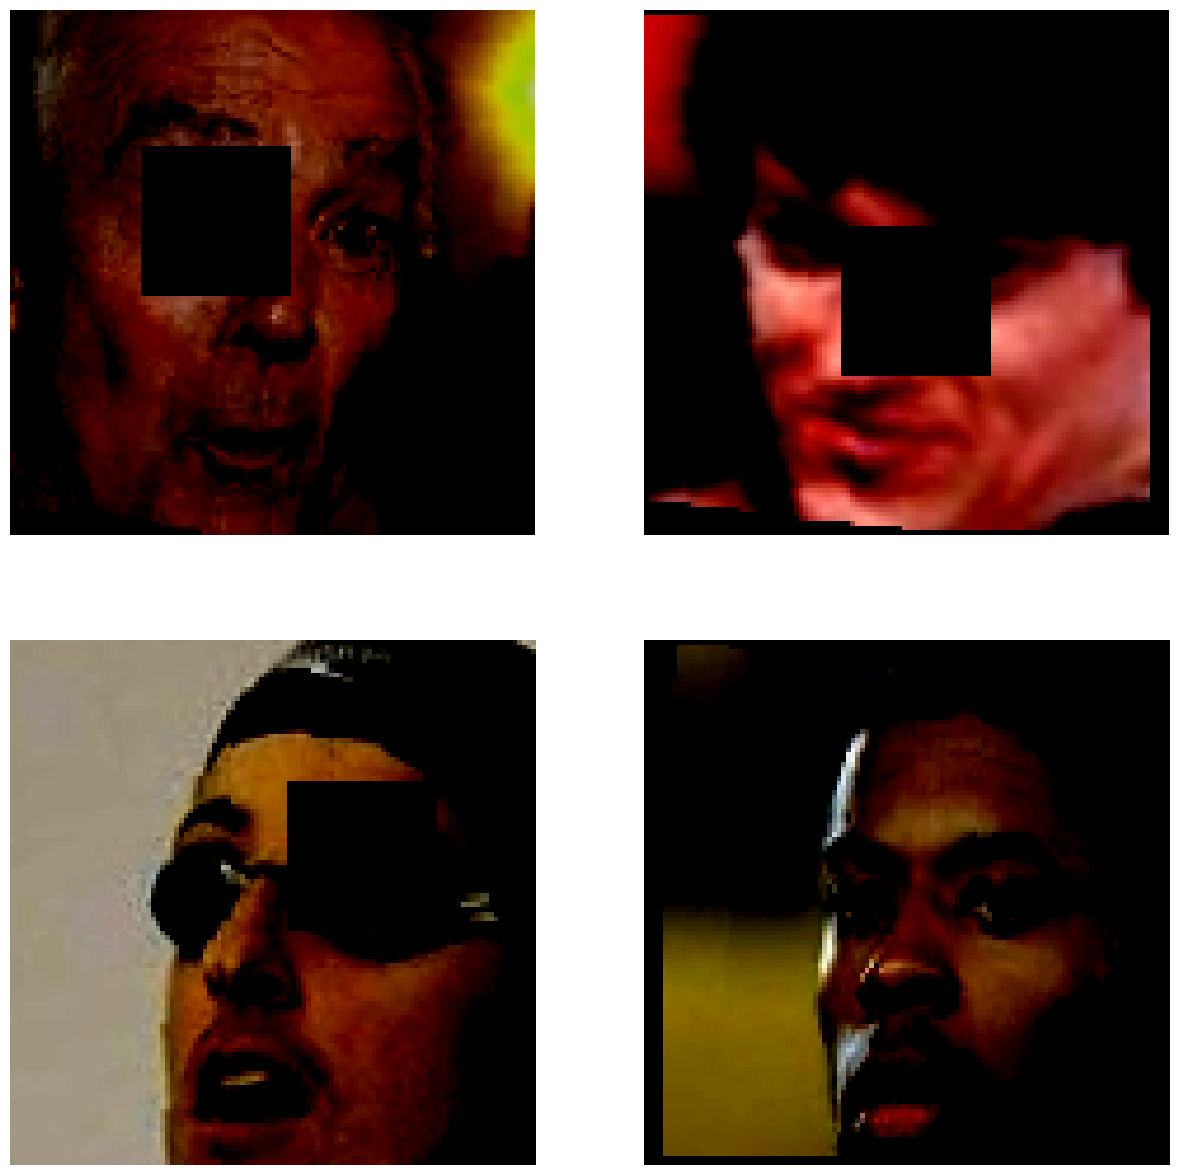

In [ ]:
# Visualize a few images in the dataset

"""
You can write your own code, and you don't need to understand the code
It is highly recommended that you visualize your data augmentation as sanity check
"""

r, c    = [2, 2]
fig, ax = plt.subplots(r, c, figsize= (15, 15))

k       = 0
dtl     = torch.utils.data.DataLoader(
    dataset     = torchvision.datasets.ImageFolder(train_dir, transform= train_transforms), # dont wanna see the images with transforms
    batch_size  = config['batch_size'],
    shuffle     = True)

for data in dtl:
    x, y = data
    print(y)

    for i in range(r):
        for j in range(c):
            img = x[k].numpy().transpose(1, 2, 0)
            ax[i, j].imshow(img)
            ax[i, j].axis('off')
            print(y[k])
            k+=1
    break

del dtl

# Model Architecture

FAQ:

**What's a very low early deadline architecture (mandatory early submission)**?

- The very low early deadline architecture is a 5-layer CNN. Keep in mind the parameter limit is 18M.
- The first convolutional layer has 64 channels, kernel size 7, and stride 4. The next three have 128, 256, 512 and 1024 channels. Each have kernel size 3 and stride 2. Documentation to make convolutional layers: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- Think about strided convolutions from the lecture, as convolutions with stride = 1 and downsampling. For strided convolution, what padding do you need for preserving the spatial resolution? (Hint => padding = kernel_size // 2) - Think why?
- Each convolutional layer is accompanied by a Batchnorm and ReLU layer.
- Finally, you want to average pool over the spatial dimensions to reduce them to 1 x 1. Use AdaptiveAvgPool2d. Documentation for AdaptiveAvgPool2d: https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveAvgPool2d.html
- Then, remove (Flatten?) these trivial 1x1 dimensions away.
Look through https://pytorch.org/docs/stable/nn.html


**Why does a very simple network have 4 convolutions**?

Input images are 112x112. Note that each of these convolutions downsample. Downsampling 2x effectively doubles the receptive field, increasing the spatial region each pixel extracts features from. Downsampling 32x is standard for most image models.

**Why does a very simple network have high channel sizes**?

Every time you downsample 2x, you do 4x less computation (at same channel size). To maintain the same level of computation, you 2x increase # of channels, which increases computation by 4x. So, balances out to same computation. Another intuition is - as you downsample, you lose spatial information. We want to preserve some of it in the channel dimension.

**What is return_feats?**

It essentially returns the second-to-last-layer features of a given image. It's a "feature encoding" of the input image, and you can use it for the verification task. You would use the outputs of the final classification layer for the classification task. You might also find that the classification outputs are sometimes better for verification too - try both.

In [ ]:
# TODO: Fill out the model definition below

class Network(torch.nn.Module):

    def __init__(self, num_classes=8631, in_channel=64, dropout=0.3):
        super().__init__()
        self.in_channel = in_channel
        self.num_classes = num_classes
        self.dropout_prob = dropout

        self.backbone = torch.nn.Sequential(
            torch.nn.Conv2d(3, self.in_channel, kernel_size=7, stride=4, padding=7//2),
            torch.nn.BatchNorm2d(self.in_channel),
            torch.nn.ReLU(inplace=True),

            torch.nn.Conv2d(self.in_channel, self.in_channel*2, kernel_size=3, stride=2, padding=3//2),
            torch.nn.BatchNorm2d(self.in_channel*2),
            torch.nn.ReLU(inplace=True),

            torch.nn.Conv2d(self.in_channel*2, self.in_channel*4, kernel_size=3, stride=2, padding=3//2),
            torch.nn.BatchNorm2d(self.in_channel*4),
            torch.nn.ReLU(inplace=True),

            torch.nn.Conv2d(self.in_channel*4, self.in_channel*8, kernel_size=3, stride=2, padding=3//2),
            torch.nn.BatchNorm2d(self.in_channel*8),
            torch.nn.ReLU(inplace=True),

            torch.nn.Conv2d(self.in_channel*8, self.in_channel*16, kernel_size=3, stride=2, padding=3//2),
            torch.nn.BatchNorm2d(self.in_channel*16),
            torch.nn.ReLU(inplace=True),

            torch.nn.AdaptiveAvgPool2d((1, 1)),
            torch.nn.Flatten(),
            )

        self.cls_layer =torch.nn.Sequential(
            # torch.nn.Linear(self.in_channel * 16, self.in_channel * 16),
            # torch.nn.Dropout(p=self.dropout_prob),  # Dropout with p=dropout_prob (e.g., 0.5)
            torch.nn.Linear(self.in_channel * 16, self.num_classes),
            )

    def forward(self, x):
        feats = self.backbone(x)
        out = self.cls_layer(feats)

        return {"feats": feats, "out": out}

# Initialize your model
model = Network().to(DEVICE)
summary(model, (3, 112, 112))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]           9,472
       BatchNorm2d-2           [-1, 64, 28, 28]             128
              ReLU-3           [-1, 64, 28, 28]               0
            Conv2d-4          [-1, 128, 14, 14]          73,856
       BatchNorm2d-5          [-1, 128, 14, 14]             256
              ReLU-6          [-1, 128, 14, 14]               0
            Conv2d-7            [-1, 256, 7, 7]         295,168
       BatchNorm2d-8            [-1, 256, 7, 7]             512
              ReLU-9            [-1, 256, 7, 7]               0
           Conv2d-10            [-1, 512, 4, 4]       1,180,160
      BatchNorm2d-11            [-1, 512, 4, 4]           1,024
             ReLU-12            [-1, 512, 4, 4]               0
           Conv2d-13           [-1, 1024, 2, 2]       4,719,616
      BatchNorm2d-14           [-1, 102

Building out Resnet-50

In [ ]:
# build out the blocks of a resnet
class ResidualBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, downsample=None, stride=1):
        super(ResidualBlock, self).__init__()
        self.expansion = 4
        self.inner_channels = out_channels // self.expansion


        # 1st conv layer in a single residual block
        self.conv1 = torch.nn.Conv2d(in_channels, self.inner_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = torch.nn.BatchNorm2d(self.inner_channels)

        # 2nd conv layer in a single residual block
        self.conv2 = torch.nn.Conv2d(self.inner_channels, self.inner_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(self.inner_channels)

        # 3rd conv layer in a single residual block
        self.conv3 = torch.nn.Conv2d(self.inner_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn3 = torch.nn.BatchNorm2d(out_channels)

        # define relu activation to be used after each layer
        self.relu = torch.nn.ReLU()
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # 1st part of a block
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # 2nd part of a block
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        # 3rd part of a block
        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# build out the blocks of a resnet
class BasicBlock(torch.nn.Module):
    def __init__(self, in_channels, out_channels, downsample=None, stride=1):
        super(BasicBlock, self).__init__()
        self.inner_channels = out_channels


        # 1st conv layer
        self.conv1 = torch.nn.Conv2d(in_channels, self.inner_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(self.inner_channels)

        # 2nd conv layer in a single residual block
        self.conv2 = torch.nn.Conv2d(self.inner_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(out_channels)

        # define relu activation to be used after each layer
        self.relu = torch.nn.ReLU()
        self.downsample = downsample

    def forward(self, x):
        identity = x

        # 1st part of a block
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # 2nd part of a block
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# Define the General Resnet
# layers is a list of integers describing how many times each block 1, 2, and 3 is called
# i.e for Resnet 50, layers = [3, 4, 6 3]; for Resnet 101, layers = [3, 4, 23, 3]
class ResNet(torch.nn.Module):
    def __init__(self, block, layers, image_channels, num_classes=8631):
        super(ResNet, self).__init__()
        self.in_channels = 64

        # first layer of a Resnet: conv with 7x7 kernel and stride 2
        self.conv1 = torch.nn.Conv2d(image_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = torch.nn.BatchNorm2d(64)
        self.relu = torch.nn.ReLU()

        # maxpool after first conv layer
        self.maxpool = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # define the rest of the layers
        # 1st block
        self.conv2_x = self._make_layer(block, layers[0], out_channels=256, stride=1)
        # 2nd block
        self.conv3_x = self._make_layer(block, layers[1], out_channels=512, stride=2)
        # 3rd block
        self.conv4_x = self._make_layer(block, layers[2], out_channels=1024, stride=2)
        # 4th block
        self.conv5_x = self._make_layer(block, layers[3], out_channels=2048, stride=2)

        self.avgpool = torch.nn.AdaptiveAvgPool2d((1, 1))
        self.fc = torch.nn.Linear(2048, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv2_x(x)
        x = self.conv3_x(x)
        x = self.conv4_x(x)
        x = self.conv5_x(x)
        x = self.avgpool(x)
        feats = torch.flatten(x, 1)
        out = self.fc(feats)
        return {"feats": feats, "out": out}

    def _make_layer(self, block, num_blocks, out_channels, stride):
        downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels:
            downsample = torch.nn.Sequential(
                torch.nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                torch.nn.BatchNorm2d(out_channels))

        layers.append(block(self.in_channels, out_channels, downsample, stride))
        self.in_channels = out_channels
        for i in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return torch.nn.Sequential(*layers)




Here my attempt was to try resnet50 architecture with a block without the bottle neck to see how the performance may differ.

In [ ]:
def ResNet50NoBottleneck(img_channel=3, num_classes=8631):
    return ResNet(BasicBlock, [3, 4, 6, 3], img_channel, num_classes)

model = ResNet50NoBottleneck().to(DEVICE)
summary(model, (3, 112, 112))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 56, 56]           9,472
       BatchNorm2d-2           [-1, 64, 56, 56]             128
              ReLU-3           [-1, 64, 56, 56]               0
         MaxPool2d-4           [-1, 64, 28, 28]               0
            Conv2d-5           [-1, 64, 28, 28]          36,928
       BatchNorm2d-6           [-1, 64, 28, 28]             128
              ReLU-7           [-1, 64, 28, 28]               0
            Conv2d-8           [-1, 64, 28, 28]          36,928
       BatchNorm2d-9           [-1, 64, 28, 28]             128
             ReLU-10           [-1, 64, 28, 28]               0
       BasicBlock-11           [-1, 64, 28, 28]               0
           Conv2d-12           [-1, 64, 28, 28]          36,928
      BatchNorm2d-13           [-1, 64, 28, 28]             128
             ReLU-14           [-1, 64,

This is a regular resnet50 architecture

In [ ]:
# create resnet 50 object
def ResNet50(img_channel=3, num_classes=8631):
    return ResNet(ResidualBlock, [3, 4, 6, 3], img_channel, num_classes)

model = ResNet50().to(DEVICE)
summary(model, (3, 112, 112))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 56, 56]           9,472
       BatchNorm2d-2           [-1, 64, 56, 56]             128
              ReLU-3           [-1, 64, 56, 56]               0
         MaxPool2d-4           [-1, 64, 28, 28]               0
            Conv2d-5           [-1, 64, 28, 28]           4,160
       BatchNorm2d-6           [-1, 64, 28, 28]             128
              ReLU-7           [-1, 64, 28, 28]               0
            Conv2d-8           [-1, 64, 28, 28]          36,928
       BatchNorm2d-9           [-1, 64, 28, 28]             128
             ReLU-10           [-1, 64, 28, 28]               0
           Conv2d-11          [-1, 256, 28, 28]          16,640
      BatchNorm2d-12          [-1, 256, 28, 28]             512
           Conv2d-13          [-1, 256, 28, 28]          16,640
      BatchNorm2d-14          [-1, 256,

For the model used in final submission, resnet18 was used. The residual block for this architecture is different than resnet50's so I created a new block and network function as follows:

In [286]:
import torch.nn as nn
import torch.nn.functional as F
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class Network(nn.Module):
    def __init__(self, num_classes=8631):
        super(Network, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # apply maxpooling after first convolutional layer
        self.maxpool = torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self.make_layer(64, 2, stride=1)
        self.layer2 = self.make_layer(128, 2, stride=2)
        self.layer3 = self.make_layer(256, 2, stride=2)
        self.layer4 = self.make_layer(512, 2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        # fully connected layer that produces embeddings
        self.fc = nn.Linear(512, 512)
        # final classification layer that output the class probabilities
        self.cls_layer = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(ResidualBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        feats = torch.flatten(out, start_dim=1)
        feats = self.fc(feats)
        out = self.cls_layer(feats)
        return {"feats": feats, "out": out}

In [287]:
model = Network().to(DEVICE)
summary(model, (3, 112, 112))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           1,728
       BatchNorm2d-2         [-1, 64, 112, 112]             128
         MaxPool2d-3           [-1, 64, 56, 56]               0
            Conv2d-4           [-1, 64, 56, 56]          36,864
       BatchNorm2d-5           [-1, 64, 56, 56]             128
            Conv2d-6           [-1, 64, 56, 56]          36,864
       BatchNorm2d-7           [-1, 64, 56, 56]             128
     ResidualBlock-8           [-1, 64, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          36,864
      BatchNorm2d-10           [-1, 64, 56, 56]             128
           Conv2d-11           [-1, 64, 56, 56]          36,864
      BatchNorm2d-12           [-1, 64, 56, 56]             128
    ResidualBlock-13           [-1, 64, 56, 56]               0
           Conv2d-14          [-1, 128,

Here we define the Loss function (criterion), the optimizer, and the scheduler. Various combinations were tried, but ultimately, CrossEntropyLoss with label_smoothing 0.1, SGD, and OneCycleLR was the final chosen.

In [ ]:

from pytorch_metric_learning import losses, regularizers
from pytorch_metric_learning.utils import common_functions as c_f
import torch

# convnext:
# resnet-50: leanring rate = 0.1; optimizer = SGD; shceulder = cosineanneal

# Defining Loss function
# criterion = torch.nn.CrossEntropyLoss()
# criterion = CrossEntropyLabelSmoothing(smoothing=0.2)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
# R = regularizers.LpRegularizer(p=2, power=1) # should be L2 distance
# ver_criterion = losses.ArcFaceLoss(num_classes=8631, embedding_size=2048, margin=28.6, scale=64, weight_regularizer=R)

# --------------------------------------------------- #

# Defining Optimizer
# optimizer =  torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-5)
optimizer = torch.optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)
# ver_optimizer = torch.optim.SGD(ver_criterion.parameters(), lr=config['lr'], momentum=0.9, weight_decay=1e-4)
# --------------------------------------------------- #

# Defining Scheduler
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=config['lr'], steps_per_epoch=len(train_loader), epochs=config['epochs'])
# scheduler = WarmupCosineAnnealingLR(optimizer, warmup_epochs=5, max_epochs=config['epochs'],min_lr=1e-6)
# cls_scheduler = torch.optim.lr_scheduler.OneCycleLR(cls_optimizer, max_lr=config['lr'], steps_per_epoch=len(train_loader), epochs=config['epochs'])
# ver_scheduler = torch.optim.lr_scheduler.OneCycleLR(ver_optimizer, max_lr=config['lr'], steps_per_epoch=len(train_loader), epochs=config['epochs'])
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'], eta_min=1e-6)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=config['lr'], steps_per_epoch=len(train_loader), epochs=config['epochs'], div_factor=10, final_div_factor=1000)
# --------------------------------------------------- #

# --------------------------------------------------- #

# Initialising mixed-precision training. # Good news. We've already implemented FP16 (Mixed precision training) for you
# It is useful only in the case of compatible GPUs such as T4/V100
scaler = torch.amp.GradScaler('cuda')

# Metrics

In [ ]:
class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [ ]:
def accuracy(output, target, topk=(1,)):
    """Computes the accuracy over the k top predictions for the specified values of k"""
    maxk = min(max(topk), output.size()[1])
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))
    return [correct[:min(k, maxk)].reshape(-1).float().sum(0) * 100. / batch_size for k in topk]

In [ ]:
def get_ver_metrics(labels, scores, FPRs):
    # eer and auc
    fpr, tpr, _ = mt.roc_curve(labels, scores, pos_label=1)
    roc_curve = interp1d(fpr, tpr)
    EER = 100. * brentq(lambda x : 1. - x - roc_curve(x), 0., 1.)
    AUC = 100. * mt.auc(fpr, tpr)

    # get acc
    tnr = 1. - fpr
    pos_num = labels.count(1)
    neg_num = labels.count(0)
    ACC = 100. * max(tpr * pos_num + tnr * neg_num) / len(labels)

    # TPR @ FPR
    if isinstance(FPRs, list):
        TPRs = [
            ('TPR@FPR={}'.format(FPR), 100. * roc_curve(float(FPR)))
            for FPR in FPRs
        ]
    else:
        TPRs = []

    return {
        'ACC': ACC,
        'EER': EER,
        'AUC': AUC,
        'TPRs': TPRs,
    }

# Train and Validation Function

In [ ]:
print(DEVICE)

cuda


In [ ]:
def check_nan(tensor, name):
    if torch.isnan(tensor).any():
        print(f"NaN detected in {name}")
        return True
    return False
def train_epoch(model, dataloader, optimizer, scheduler, scaler, device, config):

    model.train()

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()
    # top1_m = AverageMeter()
    # top5_m = AverageMeter()

    # Progress Bar
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc='Train', ncols=5)

    for i, (images, labels) in enumerate(dataloader):

        optimizer.zero_grad() # Zero gradients
        # ver_opt.zero_grad()

        # send to cuda
        images = images.to(device, non_blocking=True)
        if isinstance(labels, (tuple, list)):
            targets1, targets2, lam = labels
            targets1 = targets1.to(device, non_blocking=True)
            targets2 = targets2.to(device, non_blocking=True)
            labels = (targets1, targets2, lam)
        else:
            labels = labels.to(device, non_blocking=True)

        # forward
        with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!
            outputs = model(images)
            # # Check outputs
            # if check_nan(outputs['out'], "model outputs"):
            #     print("NaN in output")
            # if isinstance(labels, (tuple, list)):
            #     # CutMix case
            #     # print(outputs['out'].shape)
            #     # print(targets1.shape)
            #     # print(targets2.shape)
            #     # print(lam)
            #     # print(criterion(outputs['out'], targets1))
            #     # print(criterion(outputs['out'], targets2))
            #     cls_loss = lam * criterion(outputs['out'], targets1) + (1 - lam) * criterion(outputs['out'], targets2)
            # else:
                # Regular case
            cls_loss = criterion(outputs['out'], labels)

            # ver_loss = ver_criterion(F.normalize(outputs['feats']), labels)
            # print(cls_loss)
            # print(ver_loss)
            loss = cls_loss


        # Main model backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        if scheduler is not None:
          scheduler.step()
        scaler.update()


        # You may want to call some schedulers inside the train function. What are these?
        # if lr_scheduler is not None:
        #     lr_scheduler.step()

        # if ver_scheduler is not None:
        #     ver_scheduler.step()

        # metrics
        loss_m.update(loss.item())
        if 'feats' in outputs:
            # if isinstance(labels, (tuple, list)):
            #     # CutMix case
            #     top1_1, top5_1 = accuracy(outputs['out'], targets1, topk=(1, 5))
            #     top1_2, top5_2 = accuracy(outputs['out'], targets2, topk=(1, 5))
            #     top1 = top1_1 * lam + top1_2 * (1. - lam)
            #     top5 = torch.max(top5_1, top5_2)
            #     top1 = top1.item()
            #     top5 = top5.item()
            #     # acc = (lam * accuracy(outputs['out'], targets1)[0] +
            #     #        (1 - lam) * accuracy(outputs['out'], targets2)[0]).item()
            #     acc = (top1 + top5) /2
            # else:
                # Regular case
            acc = accuracy(outputs['out'], labels)[0].item()
                # top1, top5 = 0.0, 0.0
        else:
            acc = 0.0

        # top1_m.update(top1)
        # top5_m.update(top5)
        acc_m.update(acc)
        # tqdm lets you add some details so you can monitor training as you train.
        batch_bar.set_postfix(
            # acc         = "{:.04f}%".format(100*accuracy),
            acc="{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg),
            lr          = "{:.04f}".format(float(optimizer.param_groups[0]['lr'])),
            # top1        = "{:.04f} ({:.04f})".format(top1, top1_m.avg),
            # top5        = "{:.04f} ({:.04f})".format(top5, top5_m.avg))
        )


        batch_bar.update() # Update tqdm bar

        # wandb.log({
        #     'lr': float(optimizer.param_groups[0]['lr'])
        # })

    # if scheduler is not None:
    #   scheduler.step()

    batch_bar.close()

    return acc_m.avg, loss_m.avg

In [ ]:
@torch.no_grad()
def valid_epoch_cls(model, dataloader, device, config):

    model.eval()
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, position=0, leave=False, desc='Val Cls.', ncols=5)

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()

    for i, (images, labels) in enumerate(dataloader):

        # Move images to device
        images, labels = images.to(device), labels.to(device)

        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)

            cls_loss = criterion(outputs['out'], labels)
            # ver_loss = ver_criterion(F.normalize(outputs['feats']), labels)
            # print(cls_loss)
            # print(ver_loss)
            loss = cls_loss

        # metrics
        acc = accuracy(outputs['out'], labels)[0].item()
        loss_m.update(loss.item())
        acc_m.update(acc)

        batch_bar.set_postfix(
            acc         = "{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg))

        batch_bar.update()

    batch_bar.close()
    return acc_m.avg, loss_m.avg

In [ ]:
gc.collect() # These commands help you when you face CUDA OOM error
torch.cuda.empty_cache()

# Verification Task

In [ ]:
def valid_epoch_ver(model, pair_data_loader, device, config):

    model.eval()
    scores = []
    match_labels = []
    batch_bar = tqdm(total=len(pair_data_loader), dynamic_ncols=True, position=0, leave=False, desc='Val Veri.')
    for i, (images1, images2, labels) in enumerate(pair_data_loader):

        # match_labels = match_labels.to(device)
        images = torch.cat([images1, images2], dim=0).to(device)
        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)

        feats = F.normalize(outputs['feats'], dim=1).clone()
        feats1, feats2 = feats.chunk(2)
        similarity = F.cosine_similarity(feats1, feats2)
        scores.append(similarity.cpu().numpy())
        match_labels.append(labels.cpu().numpy())
        batch_bar.update()

    scores = np.concatenate(scores)
    match_labels = np.concatenate(match_labels)

    FPRs=['1e-4', '5e-4', '1e-3', '5e-3', '5e-2']
    metric_dict = get_ver_metrics(match_labels.tolist(), scores.tolist(), FPRs)
    print(metric_dict)

    return metric_dict['EER'],metric_dict['ACC']

# WandB

In [ ]:
wandb.login(key="0cc2199d5dbab5108d50abc33d06f093f13e6a18") # API Key is in your wandb account, under settings (wandb.ai/settings)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: pkotchav (pkotchav-carnegie-mellon-university). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
# Create your wandb run
run = wandb.init(
    name = "resnet50-r8-NewPreTrain", ## Wandb creates random run names if you skip this field
    reinit = True, ### Allows reinitalizing runs when you re-run this cell
    # run_id = ### Insert specific run id here if you want to resume a previous run
    # resume = "must" ### You need this to resume previous runs, but comment out reinit = True when using this
    project = "hw2p2-ablations", ### Project should be created in your wandb account
    config = config ### Wandb Config for your run
)

EER,▆██▆▇▇▅▃▃▁▁
cls_lr,▁▁▂▃▄▅▅▆▇██
train_cls_acc,▁▁▁▁▁▂▂▃▄▅█
train_loss,████▇▇▆▄▃▂▁
valid_cls_acc,▁▁▁▁▁▂▂▃▄▅█
valid_loss,████▇▆▅▄▃▃▁
valid_ret_acc,▃▁▁▂▂▂▄▆▆██
EER,32.22004
cls_lr,0.00098
train_cls_acc,0.40916
train_loss,7.9926


# Checkpointing and Loading Model

In [ ]:
# Uncomment the line for saving the scheduler save dict if you are using a scheduler
def save_model(model, optimizer, scheduler, metrics, epoch, path):
    torch.save(
        {'model_state_dict'         : model.state_dict(),
         'optimizer_state_dict'     : optimizer.state_dict(),
        #  'scheduler_state_dict'     : scheduler.state_dict(),
         'metric'                   : metrics,
         'epoch'                    : epoch},
         path)


def load_model(model, optimizer=None, scheduler=None, ver_opt=None, path='./checkpoint.pth'):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    else:
        optimizer = None
    if scheduler is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    else:
        scheduler = None
    epoch = checkpoint['epoch']
    metrics = checkpoint['metric']
    return model, optimizer, scheduler, epoch, metrics

In [283]:
model2, optimizer22, scheduler2, epoch2, metrics2 = load_model(model, None, scheduler=None, path=os.path.join(config['checkpoint_dir'], 'R8_best_cls.pth'))


<ipython-input-24-83a99be86432>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


# Experiments

In [ ]:
# Set cuDNN settings
torch.backends.cudnn.benchmark = True  # Set to True if input sizes are static
torch.backends.cudnn.enabled = True  # Ensure cuDNN is enabled

In [ ]:
e = 0
best_valid_cls_acc = 0.0
eval_cls = True
best_valid_ret_acc = 0.0
for epoch in range(e, config['epochs']):
        # epoch
        print("\nEpoch {}/{}".format(epoch+1, config['epochs']))

        # train
        train_cls_acc, train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, DEVICE, config)
        curr_lr = float(optimizer.param_groups[0]['lr'])
        print("\nEpoch {}/{}: \nTrain Cls. Acc {:.04f}%\t Train Cls. Loss {:.04f}\t Learning Rate {:.04f}".format(epoch + 1, config['epochs'], train_cls_acc, train_loss, curr_lr))
        metrics = {
            'train_cls_acc': train_cls_acc,
            'train_loss': train_loss,
            # 'train_top1': top1,
            # 'train_top5': top5
        }

        # classification validation
        if eval_cls:
            valid_cls_acc, valid_loss = valid_epoch_cls(model, val_loader, DEVICE, config)
            print("Val Cls. Acc {:.04f}%\t Val Cls. Loss {:.04f}".format(valid_cls_acc, valid_loss))
            metrics.update({
                'valid_cls_acc': valid_cls_acc,
                'valid_loss': valid_loss,
            })
            # if scheduler is not None:
            #     scheduler.step(valid_loss)


        # retrieval validation
        EER, valid_ret_acc = valid_epoch_ver(model, pair_dataloader, DEVICE, config)
        print("Val Ret. Acc {:.04f}%".format(valid_ret_acc))
        metrics.update({
            'valid_ret_acc': valid_ret_acc
        })
        metrics.update({
            'EER': EER
        })
        metrics.update({
            'cls_lr': curr_lr
        })
        # save model
        save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'R8_last.pth'))
        print("Saved epoch model")

        # save best model
        if eval_cls:
            if valid_cls_acc >= best_valid_cls_acc:
                best_valid_cls_acc = valid_cls_acc
                save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'R8_best_cls.pth'))
                wandb.save(os.path.join(config['checkpoint_dir'], 'best_cls.pth'))
                print("Saved best classification model")

        if valid_ret_acc >= best_valid_ret_acc:
            best_valid_ret_acc = valid_ret_acc
            save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'R8_best_ret.pth'))
            wandb.save(os.path.join(config['checkpoint_dir'], 'best_ret.pth'))
            print("Saved best retrieval model")

        # log to tracker
        if run is not None:
            run.log(metrics)
            # get lr of ver_optimizer
            # ver_lr = float(ver_optimizer.param_groups[0]['lr'])
            # run.log({'ver_lr': ver_lr})
            # run.log({'cls_lr': curr_lr})





Epoch 1/40


Train:   0%|          | 0/3372 [00:00<?, ?it/s]<ipython-input-439-e33df61cb32b>:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!



Epoch 1/40: 
Train Cls. Acc 0.2013%	 Train Cls. Loss 8.5316	 Learning Rate 0.0115


Val Cls. Acc 0.4900%	 Val Cls. Loss 8.0549


{'ACC': 64.7, 'EER': 35.84521384929619, 'AUC': 69.70218350745641, 'TPRs': [('TPR@FPR=1e-4', 5.906313645621181), ('TPR@FPR=5e-4', 5.906313645621181), ('TPR@FPR=1e-3', 5.906313645621181), ('TPR@FPR=5e-3', 5.906313645621181), ('TPR@FPR=5e-2', 20.366598778004075)]}
Val Ret. Acc 64.7000%
Saved epoch model
Saved best classification model
Saved best retrieval model

Epoch 2/40


...


Epoch 8/40: 
Train Cls. Acc 70.6235%	 Train Cls. Loss 2.9497	 Learning Rate 0.0775


Val Cls. Acc 76.1033%	 Val Cls. Loss 2.7318


{'ACC': 83.3, 'EER': 17.878192534375533, 'AUC': 90.37408120230954, 'TPRs': [('TPR@FPR=1e-4', 18.329938900203665), ('TPR@FPR=5e-4', 18.329938900203665), ('TPR@FPR=1e-3', 18.329938900203665), ('TPR@FPR=5e-3', 32.586558044806516), ('TPR@FPR=5e-2', 60.896130346232184)]}
Val Ret. Acc 83.3000%
Saved epoch model
Saved best classification model
Saved best retrieval model

Epoch 9/40


Train:   0%|          | 0/3372 [00:00<?, ?it/s]<ipython-input-439-e33df61cb32b>:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!
Train:  89%|████████▉ | 3001/3372 [10:19<01:07,  5.52it/s, acc=70.3125% (74.5220), loss=2.9858 (2.7687), lr=0.0859]

Buffered data was truncated after reaching the output size limit.

## Continue Training

Here I wanted to see if loading the previous pre-training run, which is done in 40 epochs, and training it a bit longer that produce better classification model. Similarly, I used cross entropy loss with label smoothing, SGD, but this time using CosineAnnealingLR scheduler instead. The starting learning rate is the one which the previous pre training optimizer was at, at the conclusion of pre-training round. <br>

Not much improvement to classification accuracies which were already at 92% but retreival accuracy seems to have increased to ~87%


In [ ]:
config = {
    'batch_size': 128, # Increase this if your GPU can handle it
    'lr': 'loaded optimizer lr (should be 0.00001)',
    'epochs': 50, # 20 epochs is recommended ONLY for the early submission - you will have to train for much longer typically.
    'data_dir': "/content/data/11-785-f24-hw2p2-verification/cls_data", #TODO
    'data_ver_dir': "/content/data/11-785-f24-hw2p2-verification/ver_data", #TODO
    'checkpoint_dir': "/content/hw2p2/run1", #TODO
    # Include other parameters as needed.
    'model_type': 'resnet smaller',
    'scheduler': 'cosineanneal',
    'optimizer': 'sgd',
    'loss': 'CE smooth',
    'description': 'continue training'
}

In [ ]:
from pytorch_metric_learning import losses, regularizers
from pytorch_metric_learning.utils import common_functions as c_f
import torch

# check = torch.load('/content/hw2p2/run1/best_cls.pth')
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)
model, optimizer, scheduler, epoch, metrics = load_model(model, optimizer, scheduler=None, path=os.path.join(config['checkpoint_dir'], 'R8_best_cls.pth'))

# R = regularizers.LpRegularizer(p=2, power=1) # should be L2 distance
# # use kaiming_uniform, with a=1 and mode='fan_out'
# weight_init_func = c_f.TorchInitWrapper(torch.nn.init.kaiming_uniform_, a=1, mode='fan_out')
# use python parametric learning library's ArcFace Loss as criterion
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
# criterion = losses.SphereFaceLoss(num_classes=8631, embedding_size=2048, margin=4, scale=64)

# Loss
# criterion = torch.nn.CrossEntropyLoss()
# SGD optimizer
# loss_optimizer = torch.optim.SGD(criterion.parameters(), lr=config['lr'], momentum=0.9, weight_decay=1e-4)
optimizer = torch.optim.SGD(model.parameters(), lr=optimizer.param_groups[0]['lr'], momentum=0.9, weight_decay=1e-4)
# set learning rate scheduler to be ReducedLRonPlateau
# step to minimize EER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'], eta_min=0)
# loss_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(loss_optimizer, T_max=config['epochs'], eta_min=0)

<ipython-input-24-83a99be86432>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


In [ ]:
# Create your wandb run
run = wandb.init(
    name = "resnet50-r8-continueTraining", ## Wandb creates random run names if you skip this field
    reinit = True, ### Allows reinitalizing runs when you re-run this cell
    # id = '7hncy5dt', ### Insert specific run id here if you want to resume a previous run
    # resume = "must", ### You need this to resume previous runs, but comment out reinit = True when using this
    project = "hw2p2-ablations", ### Project should be created in your wandb account
    config = config ### Wandb Config for your run
)

EER,█▃▂▁
cls_lr,█▇▅▁
train_cls_acc,█▁▁▁
train_loss,█▄▂▁
valid_cls_acc,█▃▂▁
valid_loss,█▅▃▁
valid_ret_acc,▁▅▆█
ver_lr,█▇▅▁
EER,14.34185
cls_lr,0.00991
train_cls_acc,1.50666


In [ ]:
def check_nan(tensor, name):
    if torch.isnan(tensor).any():
        print(f"NaN detected in {name}")
        return True
    return False
def train_epoch(model, dataloader, optimizer, scheduler, scaler, device, config):

    model.train()

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()
    # top1_m = AverageMeter()
    # top5_m = AverageMeter()

    # Progress Bar
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc='Train', ncols=5)

    for i, (images, labels) in enumerate(dataloader):

        optimizer.zero_grad() # Zero gradients
        # ver_opt.zero_grad()

        # send to cuda
        images = images.to(device, non_blocking=True)
        if isinstance(labels, (tuple, list)):
            targets1, targets2, lam = labels
            targets1 = targets1.to(device, non_blocking=True)
            targets2 = targets2.to(device, non_blocking=True)
            labels = (targets1, targets2, lam)
        else:
            labels = labels.to(device, non_blocking=True)

        # forward
        with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!
            outputs = model(images)
            # # Check outputs
            # if check_nan(outputs['out'], "model outputs"):
            #     print("NaN in output")
            # if isinstance(labels, (tuple, list)):
            #     # CutMix case
            #     # print(outputs['out'].shape)
            #     # print(targets1.shape)
            #     # print(targets2.shape)
            #     # print(lam)
            #     # print(criterion(outputs['out'], targets1))
            #     # print(criterion(outputs['out'], targets2))
            #     cls_loss = lam * criterion(outputs['out'], targets1) + (1 - lam) * criterion(outputs['out'], targets2)
            # else:
                # Regular case
            cls_loss = criterion(outputs['out'], labels)

            # ver_loss = ver_criterion(F.normalize(outputs['feats']), labels)
            # print(cls_loss)
            # print(ver_loss)
            loss = cls_loss

        # print(outputs['out'].shape)
        # if torch.isnan(cls_loss):
        #     print(f"NaN loss detected at batch {i}")
        #     print(f"Output stats: min={outputs['out'].min()}, max={outputs['out'].max()}, mean={outputs['out'].mean()}")

        # Main model backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        # if scheduler is not None:
        #   scheduler.step()
        scaler.update()

        # loss.backward()
        # optimizer.step()


        # You may want to call some schedulers inside the train function. What are these?
        # if lr_scheduler is not None:
        #     lr_scheduler.step()

        # if ver_scheduler is not None:
        #     ver_scheduler.step()

        # metrics
        loss_m.update(loss.item())
        if 'feats' in outputs:
            # if isinstance(labels, (tuple, list)):
            #     # CutMix case
            #     top1_1, top5_1 = accuracy(outputs['out'], targets1, topk=(1, 5))
            #     top1_2, top5_2 = accuracy(outputs['out'], targets2, topk=(1, 5))
            #     top1 = top1_1 * lam + top1_2 * (1. - lam)
            #     top5 = torch.max(top5_1, top5_2)
            #     top1 = top1.item()
            #     top5 = top5.item()
            #     # acc = (lam * accuracy(outputs['out'], targets1)[0] +
            #     #        (1 - lam) * accuracy(outputs['out'], targets2)[0]).item()
            #     acc = (top1 + top5) /2
            # else:
                # Regular case
            acc = accuracy(outputs['out'], labels)[0].item()
                # top1, top5 = 0.0, 0.0
        else:
            acc = 0.0

        # top1_m.update(top1)
        # top5_m.update(top5)
        acc_m.update(acc)
        # tqdm lets you add some details so you can monitor training as you train.
        batch_bar.set_postfix(
            # acc         = "{:.04f}%".format(100*accuracy),
            acc="{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg),
            lr          = "{:.04f}".format(float(optimizer.param_groups[0]['lr'])),
            # top1        = "{:.04f} ({:.04f})".format(top1, top1_m.avg),
            # top5        = "{:.04f} ({:.04f})".format(top5, top5_m.avg))
        )


        batch_bar.update() # Update tqdm bar

        # wandb.log({
        #     'lr': float(optimizer.param_groups[0]['lr'])
        # })

    # if scheduler is not None:
    #   scheduler.step()

    batch_bar.close()

    return acc_m.avg, loss_m.avg

In [ ]:
@torch.no_grad()
def valid_epoch_cls(model, dataloader, device, config):

    model.eval()
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, position=0, leave=False, desc='Val Cls.', ncols=5)

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()

    for i, (images, labels) in enumerate(dataloader):

        # Move images to device
        images, labels = images.to(device), labels.to(device)

        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)

            cls_loss = criterion(outputs['out'], labels)
            # ver_loss = ver_criterion(F.normalize(outputs['feats']), labels)
            # print(cls_loss)
            # print(ver_loss)
            loss = cls_loss

        # metrics
        acc = accuracy(outputs['out'], labels)[0].item()
        loss_m.update(loss.item())
        acc_m.update(acc)

        batch_bar.set_postfix(
            acc         = "{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg))

        batch_bar.update()

    batch_bar.close()
    return acc_m.avg, loss_m.avg

In [ ]:
gc.collect() # These commands help you when you face CUDA OOM error
torch.cuda.empty_cache()

/usr/local/lib/python3.10/dist-packages/wandb/sdk/wandb_run.py:2388: UserWarning: Run (l24zf2fo) is finished. The call to `_console_raw_callback` will be ignored. Please make sure that you are using an active run.
  lambda data: self._console_raw_callback("stderr", data),


In [ ]:
e = 0
best_valid_cls_acc = metrics['valid_cls_acc']
eval_cls = True
best_valid_ret_acc = metrics['valid_ret_acc']
best_eer = 10000
print(best_valid_cls_acc, best_valid_ret_acc)
print(optimizer.param_groups[0]['lr'])
for epoch in range(e, config['epochs']):
        # epoch
        print("\nEpoch {}/{}".format(epoch+1, config['epochs']))

        # train
        train_cls_acc, train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, DEVICE, config)
        curr_lr = float(optimizer.param_groups[0]['lr'])
        print("\nEpoch {}/{}: \nTrain Cls. Acc {:.04f}%\t Train Cls. Loss {:.04f}\t Learning Rate {:.04f}".format(epoch + 1, config['epochs'], train_cls_acc, train_loss, curr_lr))
        metrics = {
            'train_cls_acc': train_cls_acc,
            'train_loss': train_loss,
            # 'train_top1': top1,
            # 'train_top5': top5
        }

        # classification validation
        if eval_cls:
            valid_cls_acc, valid_loss = valid_epoch_cls(model, val_loader, DEVICE, config)
            print("Val Cls. Acc {:.04f}%\t Val Cls. Loss {:.04f}".format(valid_cls_acc, valid_loss))
            metrics.update({
                'valid_cls_acc': valid_cls_acc,
                'valid_loss': valid_loss,
            })
            # if scheduler is not None:
            #     scheduler.step(valid_loss)


        # retrieval validation
        EER, valid_ret_acc = valid_epoch_ver(model, pair_dataloader, DEVICE, config)
        print("Val Ret. Acc {:.04f}%".format(valid_ret_acc))
        metrics.update({
            'valid_ret_acc': valid_ret_acc
        })
        metrics.update({
            'EER': EER
        })
        metrics.update({
            'cls_lr': curr_lr
        })
        # save model
        save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'cont_R8_last.pth'))
        print("Saved epoch model")

        # save best model
        if eval_cls:
            if valid_cls_acc >= best_valid_cls_acc:
                best_valid_cls_acc = valid_cls_acc
                save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'cont_R8_best_cls.pth'))
                wandb.save(os.path.join(config['checkpoint_dir'], 'cont_R8_best_cls.pth'))
                print("Saved best classification model")

        if valid_ret_acc >= best_valid_ret_acc:
            best_valid_ret_acc = valid_ret_acc
            save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'cont_R8_best_ret.pth'))
            wandb.save(os.path.join(config['checkpoint_dir'], 'cont_R8_best_ret.pth'))
            print("Saved best retrieval model")

        if EER < best_eer:
            best_eer = EER
            save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'cont_R8_best_eer4.pth'))
            wandb.save(os.path.join(config['checkpoint_dir'], 'cont_R8_best_eer4.pth'))
            print("Saved best EER model")

        # log to tracker
        if run is not None:
            run.log(metrics)
            # get lr of ver_optimizer
            # ver_lr = float(ver_optimizer.param_groups[0]['lr'])
            # run.log({'ver_lr': ver_lr})
            # run.log({'cls_lr': curr_lr})

        if scheduler is not None:
          scheduler.step()




92.24358162513145 80.5
1.0000027676113521e-05

Epoch 1/50


Train:   0%|          | 0/3372 [00:00<?, ?it/s]<ipython-input-180-351d3bad0e7f>:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!



Epoch 1/50: 
Train Cls. Acc 97.6759%	 Train Cls. Loss 1.6201	 Learning Rate 0.0000


Val Cls. Acc 92.2644%	 Val Cls. Loss 1.9115


{'ACC': 87.3, 'EER': 13.23828920571729, 'AUC': 94.11329270683703, 'TPRs': [('TPR@FPR=1e-4', 40.73319755600815), ('TPR@FPR=5e-4', 40.73319755600815), ('TPR@FPR=1e-3', 40.73319755600815), ('TPR@FPR=5e-3', 56.41547861507128), ('TPR@FPR=5e-2', 76.37474541751527)]}
Val Ret. Acc 87.3000%
Saved epoch model
Saved best classification model
Saved best retrieval model
Saved best EER model

Epoch 2/50


...


Epoch 11/50: 
Train Cls. Acc 97.6746%	 Train Cls. Loss 1.6194	 Learning Rate 0.0000


Val Cls. Acc 92.2482%	 Val Cls. Loss 1.9078


{'ACC': 87.3, 'EER': 13.238289205702644, 'AUC': 94.17891396812567, 'TPRs': [('TPR@FPR=1e-4', 42.56619144602851), ('TPR@FPR=5e-4', 42.56619144602851), ('TPR@FPR=1e-3', 42.56619144602851), ('TPR@FPR=5e-3', 56.0081466395112), ('TPR@FPR=5e-2', 76.37474541751527)]}
Val Ret. Acc 87.3000%
Saved epoch model

Epoch 12/50


Train:   0%|          | 0/3372 [00:00<?, ?it/s]<ipython-input-180-351d3bad0e7f>:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!
Train:  31%|███       | 1031/3372 [03:20<06:49,  5.71it/s, acc=99.2188% (97.7592), loss=1.5543 (1.6170), lr=0.0000]

Buffered data was truncated after reaching the output size limit.

# Load best classification model and FineTune on Contrastive Loss further

# Finetune

For finetuning stage, after experimentation, I have chosen to remove all tranforms on the training set. The idea is that for verification task, we should have access to a snapshot of the full face without drastic augmentations like rotations, aggressive coloring, blank patches, or random erasing. Therefore, I reinitialize the dataset without those augmentations for finetuning.

In [ ]:
data_dir = config['data_dir']
# train_dir = os.path.join(data_dir)

train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'dev')

# train transforms
train_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(112), # Why are we resizing the Image?,
    # torchvision.transforms.RandomHorizontalFlip(p=0.5),
    # torchvision.transforms.ColorJitter(brightness=0.05, contrast=0.05, saturation=0.05, hue=0.05),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                      std=[0.5, 0.5, 0.5])])

# val transforms
val_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(128),
    torchvision.transforms.CenterCrop(112),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                      std=[0.5, 0.5, 0.5])])


# get datasets
train_dataset = torchvision.datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = torchvision.datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = torch.utils.data.DataLoader(train_dataset,
                                            batch_size=config["batch_size"],
                                            shuffle=True,
                                            pin_memory=True,
                                            num_workers=4,
                                            sampler=None)
val_loader = torch.utils.data.DataLoader(val_dataset,
                                          batch_size=config["batch_size"],
                                          shuffle=False,
                                          num_workers=4)

In [ ]:
config = {
    'batch_size': 128, # Increase this if your GPU can handle it
    'lr': 0.01,
    'lr_loss':1,
    'epochs': 10, # 20 epochs is recommended ONLY for the early submission - you will have to train for much longer typically.
    'data_dir': "/content/data/11-785-f24-hw2p2-verification/cls_data", #TODO
    'data_ver_dir': "/content/data/11-785-f24-hw2p2-verification/ver_data", #TODO
    'checkpoint_dir': "/content/hw2p2/run1", #TODO
    # Include other parameters as needed.
    'model_type': 'resnet smaller',
    'scheduler': 'cosineanneal',
    'optimizer': 'sgd',
    'loss': 'CircleLoss',
    'description': 'fine tune for higher Retreival'
}

Here I load the best classification model and use CircleLoss as our criterion for constrastive finetuning. The final optimizer and scheduler used was SGD and CosineAnnealingLR. The start learning rate is specified in the config

In [ ]:
from pytorch_metric_learning import losses, regularizers
from pytorch_metric_learning.utils import common_functions as c_f
import torch

# check = torch.load('/content/hw2p2/run1/best_cls.pth')
# optimizer = torch.optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)
model, optimizer, scheduler, epoch, metrics = load_model(model, None, scheduler=None, path=os.path.join(config['checkpoint_dir'], 'cont_R8_best_eer4.pth'))

# R = regularizers.LpRegularizer(p=2, power=1) # should be L2 distance
# # use kaiming_uniform, with a=1 and mode='fan_out'
# weight_init_func = c_f.TorchInitWrapper(torch.nn.init.kaiming_uniform_, a=1, mode='fan_out')
# use python parametric learning library's ArcFace Loss as criterion
# criterion = losses.ArcFaceLoss(num_classes=8631, embedding_size=512, margin=57.29, scale=64)
# criterion = losses.SphereFaceLoss(num_classes=8631, embedding_size=512, margin=4, scale=64)
criterion = losses.CircleLoss(m=0.25, gamma=80)

# Loss
# criterion = torch.nn.CrossEntropyLoss()
# SGD optimizer
# loss_optimizer = torch.optim.SGD(criterion.parameters(), lr=config['lr_loss'], momentum=0.9, weight_decay=1e-4)
optimizer = torch.optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=1e-4)
# set learning rate scheduler to be ReducedLRonPlateau
# step to minimize EER
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'], eta_min=0)
# loss_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(loss_optimizer, T_max=config['epochs'], eta_min=0)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=config['lr'], steps_per_epoch=len(train_loader), epochs=config['epochs'], div_factor=10, final_div_factor=1000)
# loss_scheduler = torch.optim.lr_scheduler.OneCycleLR(loss_optimizer, max_lr=config['lr_loss'], steps_per_epoch=len(train_loader), epochs=config['epochs'], div_factor=10, final_div_factor=1000)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=1, verbose=True)
# loss_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(loss_optimizer, mode='max', factor=0.1, patience=1, verbose=True)

<ipython-input-24-83a99be86432>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


Then, I frozed the weight of all layers except the linear layer that produces the embedding. I am attempting to only train this layer for the verification task.

In [ ]:
# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the second-to-last layer
# Assuming the model has a sequential structure or named layers
# The second-to-last layer can be accessed based on the architecture
# For example, if using nn.Sequential or a list of layers

# Option 1: If using a Sequential model
second_to_last_layer = list(model.children())[-2]  # Get the second-to-last layer
for param in second_to_last_layer.parameters():
    param.requires_grad = True

# Option 2: If the model has named layers, you can access the second-to-last layer directly
# For example, if the layer is called 'fc2'
# for param in model.fc2.parameters():
#     param.requires_grad = True

# Verify which layers are trainable
for name, param in model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")


conv1.weight: requires_grad=False
bn1.weight: requires_grad=False
bn1.bias: requires_grad=False
layer1.0.conv1.weight: requires_grad=False
layer1.0.bn1.weight: requires_grad=False
layer1.0.bn1.bias: requires_grad=False
layer1.0.conv2.weight: requires_grad=False
layer1.0.bn2.weight: requires_grad=False
layer1.0.bn2.bias: requires_grad=False
layer1.1.conv1.weight: requires_grad=False
layer1.1.bn1.weight: requires_grad=False
layer1.1.bn1.bias: requires_grad=False
layer1.1.conv2.weight: requires_grad=False
layer1.1.bn2.weight: requires_grad=False
layer1.1.bn2.bias: requires_grad=False
layer2.0.conv1.weight: requires_grad=False
layer2.0.bn1.weight: requires_grad=False
layer2.0.bn1.bias: requires_grad=False
layer2.0.conv2.weight: requires_grad=False
layer2.0.bn2.weight: requires_grad=False
layer2.0.bn2.bias: requires_grad=False
layer2.0.shortcut.0.weight: requires_grad=False
layer2.0.shortcut.1.weight: requires_grad=False
layer2.0.shortcut.1.bias: requires_grad=False
layer2.1.conv1.weight: r

In [ ]:
# Create your wandb run
run = wandb.init(
    name = "resnet50-r8-higherRetTune16", ## Wandb creates random run names if you skip this field
    reinit = True, ### Allows reinitalizing runs when you re-run this cell
    # id = '7hncy5dt', ### Insert specific run id here if you want to resume a previous run
    # resume = "must", ### You need this to resume previous runs, but comment out reinit = True when using this
    project = "hw2p2-ablations", ### Project should be created in your wandb account
    config = config ### Wandb Config for your run
)

EER,▁
cls_lr,▁
train_cls_acc,▁
train_loss,▁
valid_cls_acc,▁
valid_loss,▁
valid_ret_acc,▁
ver_lr,▁
EER,15.88595
cls_lr,0.01
train_cls_acc,23.98113


/usr/local/lib/python3.10/dist-packages/wandb/sdk/wandb_run.py:2388: UserWarning: Run (1oypc4w1) is finished. The call to `_console_raw_callback` will be ignored. Please make sure that you are using an active run.
  lambda data: self._console_raw_callback("stderr", data),


I reintialize train_epoch function and validation_epoch_cls function for verification task by using normalized output['feats'] (the features) instead of output['out] (class probabilities) in the Loss function. 

In [ ]:
def train_epoch(model, dataloader, optimizer, lr_scheduler, loss_optimizer, scaler, device, config):

    model.train()

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()

    # Progress Bar
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc='Train', ncols=5)

    for i, (images, labels) in enumerate(dataloader):

        optimizer.zero_grad() # Zero gradients
        if loss_optimizer is not None:
          loss_optimizer.zero_grad()

        # send to cuda
        images = images.to(device, non_blocking=True)
        if isinstance(labels, (tuple, list)):
            targets1, targets2, lam = labels
            labels = (targets1.to(device), targets2.to(device), lam)
        else:
            labels = labels.to(device, non_blocking=True)

        # forward
        with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!
            outputs = model(images)

            # Use the type of output depending on the loss function you want to use
            loss = criterion(F.normalize(outputs['feats']), labels)

        scaler.scale(loss).backward() # This is a replacement for loss.backward()
        scaler.step(optimizer) # This is a replacement for optimizer.step()
        if loss_optimizer is not None:
          scaler.step(loss_optimizer)
        if lr_scheduler is not None:
            lr_scheduler.step()
        scaler.update()

        # You may want to call some schedulers inside the train function. What are these?
        # if lr_scheduler is not None:
        #     lr_scheduler.step()

        # metrics
        loss_m.update(loss.item())
        if 'feats' in outputs:
            acc = accuracy(outputs['out'], labels)[0].item()
        else:
            acc = 0.0
        acc_m.update(acc)

        # tqdm lets you add some details so you can monitor training as you train.
        batch_bar.set_postfix(
            # acc         = "{:.04f}%".format(100*accuracy),
            acc="{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg),
            lr          = "{:.04f}".format(float(optimizer.param_groups[0]['lr'])))

        batch_bar.update() # Update tqdm bar

    batch_bar.close()

    return acc_m.avg, loss_m.avg

In [ ]:
@torch.no_grad()
def valid_epoch_cls(model, dataloader, device, config):

    model.eval()
    batch_bar = tqdm(total=len(dataloader), dynamic_ncols=True, position=0, leave=False, desc='Val Cls.', ncols=5)

    # metric meters
    loss_m = AverageMeter()
    acc_m = AverageMeter()

    for i, (images, labels) in enumerate(dataloader):

        # Move images to device
        images, labels = images.to(device), labels.to(device)

        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)

            # cls_loss = criterion(outputs['feats'], labels)
            ver_loss = criterion(F.normalize(outputs['feats']), labels)
            # print(cls_loss)
            # print(ver_loss)
            loss = ver_loss

        # metrics
        acc = accuracy(outputs['out'], labels)[0].item()
        loss_m.update(loss.item())
        acc_m.update(acc)

        batch_bar.set_postfix(
            acc         = "{:.04f}% ({:.04f})".format(acc, acc_m.avg),
            loss        = "{:.04f} ({:.04f})".format(loss.item(), loss_m.avg))

        batch_bar.update()

    batch_bar.close()
    return acc_m.avg, loss_m.avg

In [ ]:
gc.collect() # These commands help you when you face CUDA OOM error
torch.cuda.empty_cache()

In [ ]:
e = 0
best_valid_cls_acc = metrics['valid_cls_acc']
eval_cls = True
best_valid_ret_acc = metrics['valid_ret_acc']
best_eer = 10000
print(best_valid_cls_acc, best_valid_ret_acc)
print(optimizer.param_groups[0]['lr'])
for epoch in range(e, config['epochs']):
        # epoch
        print("\nEpoch {}/{}".format(epoch+1, config['epochs']))

        # train
        train_cls_acc, train_loss = train_epoch(model, train_loader, optimizer, None, None, scaler, DEVICE, config)
        curr_lr = float(optimizer.param_groups[0]['lr'])
        loss_lr = float(loss_optimizer.param_groups[0]['lr'])
        print("\nEpoch {}/{}: \nTrain Cls. Acc {:.04f}%\t Train Cls. Loss {:.04f}\t Learning Rate {:.04f}".format(epoch + 1, config['epochs'], train_cls_acc, train_loss, curr_lr))
        metrics = {
            'train_cls_acc': train_cls_acc,
            'train_loss': train_loss,
            # 'train_top1': train_top1,
            # 'train_top5': train_top5
        }
        # classification validation
        if eval_cls:
            valid_cls_acc, valid_loss = valid_epoch_cls(model, val_loader, DEVICE, config)
            print("Val Cls. Acc {:.04f}%\t Val Cls. Loss {:.04f}".format(valid_cls_acc, valid_loss))
            metrics.update({
                'valid_cls_acc': valid_cls_acc,
                'valid_loss': valid_loss,
            })

        # retrieval validation
        EER, valid_ret_acc = valid_epoch_ver(model, pair_dataloader, DEVICE, config)
        print("Val Ret. Acc {:.04f}%".format(valid_ret_acc))
        metrics.update({
            'valid_ret_acc': valid_ret_acc
        })
        metrics.update({
            'EER': EER
        })
        metrics.update({
            'cls_lr': curr_lr,
            'ver_lr': loss_lr
        })
        # save model
        save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'VerTune8_last4.pth'))
        print("Saved epoch model")

        # save best model
        if eval_cls:
            if valid_cls_acc >= best_valid_cls_acc:
                best_valid_cls_acc = valid_cls_acc
                save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'VerTune8_best_cls4.pth'))
                wandb.save(os.path.join(config['checkpoint_dir'], 'VerTune8_best_cls4.pth'))
                print("Saved best classification model")

        if valid_ret_acc >= best_valid_ret_acc:
            best_valid_ret_acc = valid_ret_acc
            save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'VerTune8_best_ret4.pth'))
            wandb.save(os.path.join(config['checkpoint_dir'], 'VerTune8_best_ret4.pth'))
            print("Saved best retrieval model")

        if EER < best_eer:
            best_eer = EER
            save_model(model, optimizer, scheduler, metrics, epoch, os.path.join(config['checkpoint_dir'], 'VerTune8_best_eer4.pth'))
            wandb.save(os.path.join(config['checkpoint_dir'], 'VerTune8_best_eer4.pth'))
            print("Saved best EER model")

        # log to tracker
        if run is not None:
            run.log(metrics)
            # get lr of ver_optimizer
            # ver_lr = float(ver_optimizer.param_groups[0]['lr'])
            # run.log({'ver_lr': ver_lr})
            # run.log({'cls_lr': curr_lr})
        # Step the learning rate scheduler after each epoch
        # if loss_scheduler is not None:
        #     loss_scheduler.step()
        if scheduler is not None:
            scheduler.step()

92.23202467246874 87.3
0.01

Epoch 1/10


Train:   0%|          | 0/3372 [00:00<?, ?it/s]<ipython-input-275-fc257629bf23>:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!



Epoch 1/10: 
Train Cls. Acc 88.5786%	 Train Cls. Loss 13.5913	 Learning Rate 0.0100


Val Cls. Acc 69.8926%	 Val Cls. Loss 31.7346


{'ACC': 87.5, 'EER': 12.573673870423185, 'AUC': 94.91155134263501, 'TPRs': [('TPR@FPR=1e-4', 36.456211812627295), ('TPR@FPR=5e-4', 36.456211812627295), ('TPR@FPR=1e-3', 36.456211812627295), ('TPR@FPR=5e-3', 38.69653767820774), ('TPR@FPR=5e-2', 77.18940936863544)]}
Val Ret. Acc 87.5000%
Saved epoch model
Saved best retrieval model
Saved best EER model

Epoch 2/10


...

{'ACC': 91.0, 'EER': 9.4302554026473, 'AUC': 96.50486757709498, 'TPRs': [('TPR@FPR=1e-4', 55.80448065173116), ('TPR@FPR=5e-4', 55.80448065173116), ('TPR@FPR=1e-3', 55.80448065173116), ('TPR@FPR=5e-3', 60.692464358452135), ('TPR@FPR=5e-2', 83.91038696537679)]}
Val Ret. Acc 91.0000%
Saved epoch model

Epoch 10/10


Train:   0%|          | 0/3372 [00:00<?, ?it/s]<ipython-input-275-fc257629bf23>:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():  # This implements mixed precision. Thats it!



Epoch 10/10: 
Train Cls. Acc 85.1818%	 Train Cls. Loss 11.6526	 Learning Rate 0.0002


Val Cls. Acc 73.4978%	 Val Cls. Loss 29.7482


{'ACC': 91.0, 'EER': 9.368635437857185, 'AUC': 96.56508708821659, 'TPRs': [('TPR@FPR=1e-4', 57.43380855397149), ('TPR@FPR=5e-4', 57.43380855397149), ('TPR@FPR=1e-3', 57.43380855397149), ('TPR@FPR=5e-3', 61.5071283095723), ('TPR@FPR=5e-2', 82.4847250509165)]}
Val Ret. Acc 91.0000%
Saved epoch model


# Testing and Kaggle Submission (Verification)

In [ ]:
def test_epoch_ver(model, pair_data_loader, config):

    model.eval()
    scores = []
    batch_bar = tqdm(total=len(pair_data_loader), dynamic_ncols=True, position=0, leave=False, desc='Val Veri.')
    for i, (images1, images2) in enumerate(pair_data_loader):

        images = torch.cat([images1, images2], dim=0).to(DEVICE)
        # Get model outputs
        with torch.inference_mode():
            outputs = model(images)

        feats = F.normalize(outputs['feats'], dim=1)
        feats1, feats2 = feats.chunk(2)
        similarity = F.cosine_similarity(feats1, feats2)
        scores.extend(similarity.cpu().numpy().tolist())
        batch_bar.update()

    return scores

In [ ]:
checkpoint = torch.load(os.path.join('/content/hw2p2/run1', 'VerTune8_best_ret4.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
scores = test_epoch_ver(model, test_pair_dataloader, config)

<ipython-input-277-a2ff68196122>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(os.path.join('/content/hw2p2/run1', 'VerTune8_best_ret4.pth'))


In [ ]:
with open("verification_submission10.csv", "w+") as f:
    f.write("ID,Label\n")
    for i in range(len(scores)):
        f.write("{},{}\n".format(i, scores[i]))

In [ ]:
run.finish()

EER,█▆▆▃▄▄▁▂▂▂
cls_lr,██▇▇▆▄▃▂▂▁
train_cls_acc,█▃▁▁▂▂▃▄▄▄
train_loss,█▆▄▃▃▂▂▂▂▁
valid_cls_acc,▁▄▂▃▃▅▅▇██
valid_loss,██▆▅▄▂▂▁▁▁
valid_ret_acc,▁▄▄▆▅▆█▇▇▇
ver_lr,▁▁▁▁▁▁▁▁▁▁
EER,9.36864
cls_lr,0.00024
train_cls_acc,85.18179
